<a href="https://colab.research.google.com/github/tradingwithme/Works-w-ML-and-w-o-ML/blob/main/Webdriver_with_unsloth_qna-based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initiate Webdriver

In [1]:
!pip install -q selenium undetected_chromedriver selenium_stealth
# Downloading the chromedriver to Kaggle
!wget https://chromedriver.storage.googleapis.com/LATEST_RELEASE

# Read the latest release version
with open('LATEST_RELEASE', 'r') as f:
    latest_version = f.read().strip()

# Downloading the chromedriver to Kaggle using the latest version
!wget https://chromedriver.storage.googleapis.com/{latest_version}/chromedriver_linux64.zip

# Making that file executable
!chmod 755 /content/chromedriver_linux64.zip
# Dowloading Google Chrome's latest stable version to Kaggle
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb

# Installing Google Chrome
!sudo apt install ./google-chrome-stable_current_amd64.deb -y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.3 MB/s eta 0:00:00
--2025-09-27 19:43:23--  https://chromedriver.storage.googleapis.com/LATEST_RELEASE
Resolving chromedriver.storage.googleapis.com (chromedriver.storage.googleapis.com)... 108.177.12.207, 173.194.210.207, 74.125.26.207, ...
Connecting to chromedriver.storage.googleapis.com (chromedriver.storage.googleapis.com)|108.177.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13 [text/plain]
Saving to: ‘LATEST_RELEASE’

LATEST_RELEASE      100%[===================>]      13  --.-KB/s    in 0s      

2025-09-27 19:43:23 (3.06 MB/s) - ‘LATEST_RELEASE’ saved [13/13]

--2025-09-27 19:43:23--  https://chromedriver.stora

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from json import dump
from io import BytesIO
from time import sleep
from bs4 import BeautifulSoup
from selenium import webdriver
from typing import Union, Tuple
from random import sample, choice
from IPython.display import display
from selenium_stealth import stealth
from selenium.common.exceptions import *
from undetected_chromedriver import Chrome
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.remote.webdriver import WebDriver
from selenium.webdriver.remote.webelement import WebElement
from selenium.webdriver.support.ui import WebDriverWait as wait
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support import expected_conditions as EC

In [3]:
def getLast(driver,cssSelector):
  driver.implicitly_wait(15)
  css_caller, css_element = cssSelector
  return driver.find_elements(css_caller,css_element)[-1]
def forceClick(driver, element): driver.execute_script("arguments[0].click();", element)
def displayWebElement(webelement):
  if hasattr(webelement, 'screenshot_as_png'): display(Image.open(BytesIO(webelement.screenshot_as_png)))
  else: display(Image.open(BytesIO(webelement.get_screenshot_as_png())))
def isChecked(driver,element): driver.execute_script("return arguments[0].checked;", element)
def displayWebElement(webelement):
  if hasattr(webelement, 'screenshot_as_png'): display(Image.open(BytesIO(webelement.screenshot_as_png)))
  else: display(Image.open(BytesIO(webelement.get_screenshot_as_png())))
def getWebHTML(element): return BeautifulSoup(element.get_attribute('outerHTML'), 'html.parser')
def find_element_by_attribute_value(soup, text):
    found_elements = []
    for tag in soup.find_all():
        for attr, value in tag.attrs.items():
            if isinstance(value, str) and text in value:
                found_elements.append(tag)
                break  # Stop checking attributes for this tag once a match is found
    return found_elements
def scroll_to_and_focus_element(driver, element):
    driver.execute_script("arguments[0].scrollIntoView();", element)
    sleep(0.5)
    driver.execute_script("arguments[0].style.border='3px solid red';", element)
def bringToFocus(driver, element):
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", element)
    driver.execute_script("arguments[0].focus();", element)
def sanitizeText(Text): return ' '.join(j for i in Text.splitlines() for j in i.split(' ') if j!='')
def getHTML(driver): return BeautifulSoup(driver.page_source,'html.parser')
def bringToFocus(driver, element):
  for i in range(15):
      driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", element)
      driver.execute_script("arguments[0].focus();", element)
      scroll_to_and_focus_element(driver,element)
      if element.is_displayed() and element.is_enabled(): break
      else: sleep(1.1)
def clearEntry(driver,element):
    driver.execute_script("arguments[0].scrollIntoView(true);",element)
    for i in range(3):
      element.send_keys(Keys.CONTROL + 'a')
      element.send_keys(Keys.DELETE)
      element.send_keys(Keys.CONTROL + 'a')
      element.send_keys(Keys.BACKSPACE)
      sleep(0.1)
      ActionChains(driver).key_down(Keys.CONTROL).send_keys_to_element(element,'a').key_up(Keys.CONTROL).send_keys_to_element(element,Keys.BACKSPACE).perform()
def visElement(driver,cssSelector,timer=10,showAny=False,showAll=False,selectOne=True):
  driver.implicitly_wait(timer)
  css_caller, css_element = cssSelector
  if (css_caller == By.CSS_SELECTOR and getHTML(driver).select(css_element)) or (css_caller!=By.CSS_SELECTOR and driver.find_elements(css_caller,css_element)):
    while any(i.is_displayed() and i.is_enabled() for i in driver.find_elements(css_caller,css_element)):
      try:
        if showAny:
          elements = wait(driver,timer).until(EC.visibility_of_any_elements_located((css_caller,css_element)))
          return elements if selectOne is False else elements[-1]
        elif showAll and all(i.is_displayed() and i.is_enabled() for i in driver.find_elements(css_caller,css_element)):
          elements = wait(driver,timer).until(EC.visibility_of_all_elements_located((css_caller,css_element)))
          return elements if selectOne is False else elements[-1]
        elif selectOne and driver.find_element(css_caller,css_element).is_displayed() and driver.find_element(css_caller,css_element).is_enabled(): return wait(driver,timer).until(EC.presence_of_element_located((css_caller,css_element)))
        else:
          elements = wait(driver,timer).until(EC.visibility_of_any_elements_located((css_caller,css_element)))
          return elements if selectOne is False else elements[-1]
      except StaleElementReferenceException: continue
    #if selectOne: return driver.find_elements(css_caller,css_element)[-1]
    #else: return driver.find_elements(css_caller,css_element)
  print(f'Element {str(cssSelector)} not found')
  return None if selectOne else []
def sfe(driver: WebDriver, selector: By, css: str, waitTime: int = 20) -> WebElement:
    """
    Waits for an element to be clickable, scrolls it into view, and moves the mouse to it.

    Args:
        driver: The Selenium WebDriver instance.
        selector: The locator strategy (e.e., By.ID).
        css: The locator value (e.g., 'my-element').
        waitTime: The maximum time in seconds to wait for the element to be clickable.

    Returns:
        The WebElement that was interacted with. Returns None if the element is not found within the timeout.
    """
    driver.implicitly_wait(waitTime)
    if ((selector == By.CSS_SELECTOR) and getHTML(driver).select(css)) or (selector != By.CSS_SELECTOR and driver.find_elements(selector, css)):
      while any([element.is_displayed() and element.is_enabled() for element in driver.find_elements(selector, css)]):
          wait_obj = wait(driver, waitTime)
          locator = (selector, css)
          element = wait_obj.until(EC.element_to_be_clickable(locator))
          driver.execute_script("arguments[0].scrollIntoView(true);", element)
          ActionChains(driver).move_to_element(element).perform()
      #except TimeoutException:
      #print(f"Timed out waiting for element located by {locator} to be clickable.")
    print(f'Element {str(selector,css)} is not found.')
    return None
def assignText(driver,element,text):
    escaped_text = text.replace('\\', '\\\\').replace("'", "\\'").replace('\n', '\\n').replace('\r', '\\r')
    driver.execute_script(f"arguments[0].value = '{escaped_text}';", element)
    driver.execute_script(f"arguments[0].textContent = '{escaped_text}';", element)
def displayImage(WebObject):
  """
  Displays an image from a Selenium WebDriver or WebElement.

  Args:
    WebObject: A Selenium WebDriver or WebElement.
  """
  if WebObject is None:
    print("WebObject is None.")
    return
  elif isinstance(WebObject, WebDriver):
    print("Processing WebDriver.")
    # Take a screenshot of the entire page
    screenshot_bytes = WebObject.get_screenshot_as_png()
    image = Image.open(BytesIO(screenshot_bytes))
    display(image) # Display the image in Colab
  elif isinstance(WebObject, WebElement):
    print("Processing WebElement.")
    # Take a screenshot of the element
    screenshot_bytes = WebObject.screenshot_as_png
    image = Image.open(BytesIO(screenshot_bytes))
    display(image) # Display the image in Colab
  else: print(f"Unsupported object type: {type(WebObject)}")
def getDriver(disable_gpu=False, headless_mode=False, background_mode=False):
    """
    Returns a Selenium WebDriver instance based on the given settings.
    Supports cross-platform operation for Linux, macOS, and Windows.
    """
    options = Options()
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-setuid-sandbox')
    options.add_argument('--headless')
    options.add_argument('--disable-gpu')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--remote-debugging-port=9222')
    service = Service('/usr/bin/google-chrome')
    user_agent = [
"Mozilla/5.0 (Linux; Android 4.4.4; [HM NOTE|NOTE-III|NOTE2 1LTET) AppleWebKit/537.39 (KHTML, like Gecko)  Chrome/53.0.2111.335 Mobile Safari/536.6",
"Mozilla / 5.0 (compatible; MSIE 8.0; Windows; U; Windows NT 6.2; x64; en-US Trident / 4.0)",
"Mozilla/5.0 (iPhone; CPU iPhone OS 8_0_8; like Mac OS X) AppleWebKit/536.13 (KHTML, like Gecko)  Chrome/50.0.2440.333 Mobile Safari/600.1",
"Mozilla/5.0 (iPod; CPU iPod OS 11_1_7; like Mac OS X) AppleWebKit/603.49 (KHTML, like Gecko)  Chrome/51.0.1709.273 Mobile Safari/533.6"
]
    options.add_argument('--user-agent=%s' % choice(user_agent))
    driver = Chrome(service=service, options=options)
    stealth(driver, languages=['en-US', 'en'], vendor="Google Inc.", platform="Win32", webgl_vendor="Intel Inc.", render="Intel Iris OpenGL Engine", fix_hairline=True)
    return driver

In [4]:
from google.colab import userdata

In [5]:
driver = getDriver()
print("WebDriver initialized successfully.")

WebDriver initialized successfully.


# New Section

In [26]:
!pip install -q chromadb
!pip install -U -q langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.8/510.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 29.4 MB/s eta 0:00

In [6]:
!pip install -q unsloth transformers peft accelerate trl bitsandbytes langchain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.5/132.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 7.3 MB/s eta 0:00:00


In [7]:
driver.get('https://apply.workable.com/j/588D70972C')
visElement(driver,(By.TAG_NAME,'body'),showAny=True,selectOne=False);

In [12]:
driver.implicitly_wait(15)
if getHTML(driver).select('[data-ui="cookie-consent-accept"]'):
    element = visElement(driver,(By.CSS_SELECTOR,'[data-ui="cookie-consent-accept"]'),showAny=True,selectOne=True)
    if element: element.click()

In [13]:
visElement(driver,(By.CSS_SELECTOR,'[role="listitem"]')).click()
sleep(1.5)
visElement(driver,(By.TAG_NAME,'body'),showAny=True,selectOne=False);

In [14]:
jobDescription = getHTML(driver).find('section').find('div')#.get_text(strip=True)

In [49]:
#visElement(driver,(By.CSS_SELECTOR,'[data-ui="apply-button"]')).click()

In [13]:
from IPython.display import HTML
HTML(jobDescription.prettify())

In [15]:
with open('jobDescription.txt','w') as file: file.write(jobDescription.prettify())

In [55]:
[i.get_attribute('name') for i in visElement(driver,(By.CSS_SELECTOR,'input[name]'),showAny=True,selectOne=False)]

['firstname', 'lastname', 'email', 'headline', 'phone', 'address']

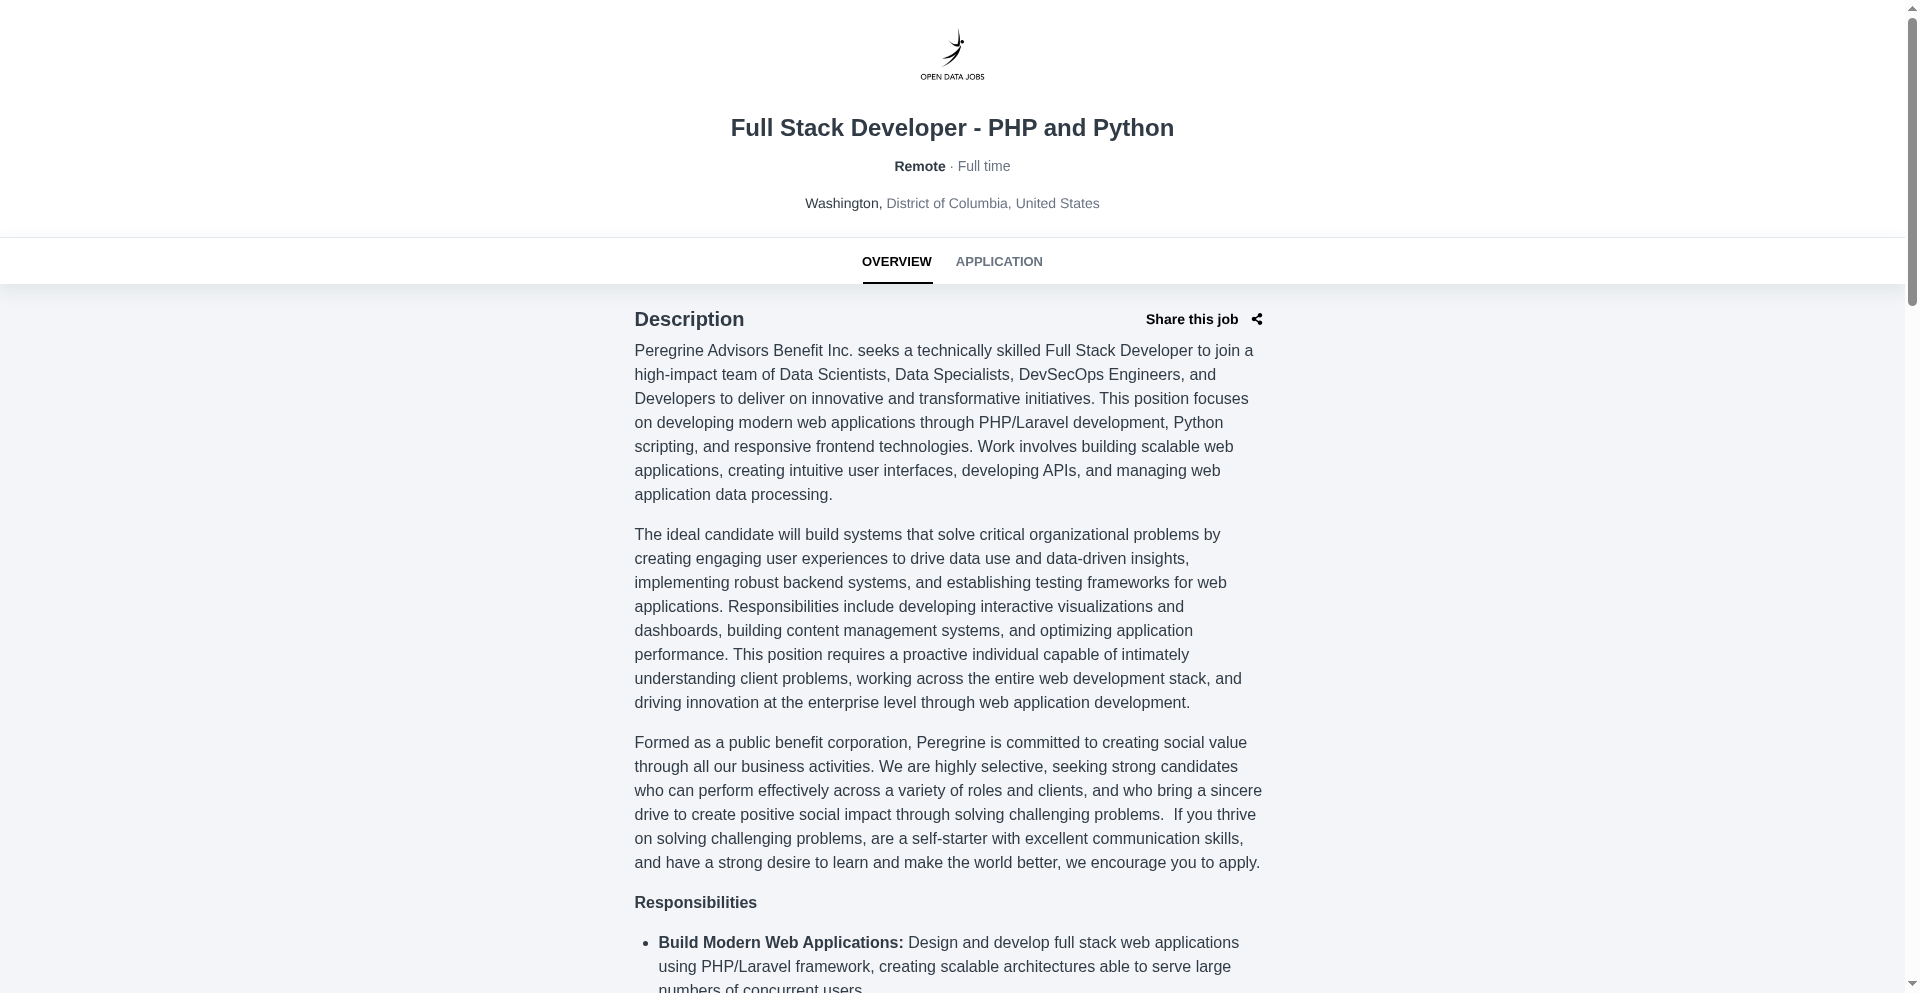

In [16]:
displayWebElement(driver)

In [17]:
from json import load; credentials = load(open('credentials.json','r'))

In [18]:
qna_list = [({'input':key},
{'output':''.join('<li>'+i+'</li>' for i in value) if isinstance(value, list) else '<li>'+str(value)+'</li>'}) for key, value in credentials.items()]

In [19]:
from pickle import dump; dump(qna_list,open('qna_list.pkl','wb'))

# Task
Fine-tune a QnA model using Unsloth, LangChain, and HuggingFace on the data in "/content/qna_list.pkl".

## Load the qna data

### Subtask:
Load the QnA data from the provided pickle file `/content/qna_list.pkl`.


**Reasoning**:
Import the pickle library and load the data from the pickle file into the `qna_data` variable.



In [20]:
import pickle
with open('/content/qna_list.pkl', 'rb') as f:
    qna_data = pickle.load(f)

## Prepare the data for training

### Subtask:
Format the loaded QnA data into a suitable format for training with a language model.


**Reasoning**:
Format the loaded QnA data into a suitable format for training with a language model by defining a formatting function and applying it to each QnA pair.



In [21]:
def format_qna(qna_pair):
    """Formats a QnA pair into a string suitable for language model training."""
    input_text = qna_pair[0]['input']
    output_text = qna_pair[1]['output']
    return f"### Input:\n{input_text}\n\n### Output:\n{output_text}"

formatted_qna_data = [format_qna(pair) for pair in qna_data]
print(formatted_qna_data[0])

### Input:
First Name

### Output:
<li>Michael</li>


## Load and prepare the model

### Subtask:
Load a pre-trained language model using Unsloth and prepare it for fine-tuning.


**Reasoning**:
Import necessary functions from unsloth and load and prepare the model for training.



In [22]:
from unsloth import FastLanguageModel

max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-2-7b-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    use_gradient_checkpointing=True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.9.9: Fast Llama patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.87G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/183 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/948 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Unsloth 2025.9.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## Setup the training environment

### Subtask:
Configure the training arguments and create a trainer object for the fine-tuning process.


**Reasoning**:
Configure the training arguments and create a trainer object for the fine-tuning process.



In [23]:
from transformers import Trainer, TrainingArguments

training_arguments = TrainingArguments(
per_device_train_batch_size=2,
gradient_accumulation_steps=4,
warmup_steps=5,
max_steps=60,
learning_rate=2e-4,
fp16=True,
logging_steps=1,
output_dir="outputs",
optim="adamw_8bit",
)

trainer = Trainer(
model=model,
train_dataset=formatted_qna_data,
#tokenizer=tokenizer,
processing_class=tokenizer,
args=training_arguments,
)

## Train the model

### Subtask:
Fine-tune the model on the prepared QnA data.


**Reasoning**:
Initiate the training process using the configured trainer object.



In [24]:
from torch.utils.data import Dataset
class QnADataset(Dataset):
    def __init__(self, data, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.tokenized_data = []
        for item in data:
            tokenized_item = self.tokenizer(
                item,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt'
            )
            self.tokenized_data.append({
                'input_ids': tokenized_item['input_ids'].squeeze(),
                'attention_mask': tokenized_item['attention_mask'].squeeze(),
                'labels': tokenized_item['input_ids'].squeeze().clone()
            })

    def __len__(self):
        return len(self.tokenized_data)

    def __getitem__(self, idx):
        return self.tokenized_data[idx]
train_dataset = QnADataset(formatted_qna_data, tokenizer, max_seq_length)
trainer.train_dataset = train_dataset

In [27]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,559 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 39,976,960 of 6,778,392,576 (0.59% trained)
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: michael-ojeranti (michael-ojeranti-long-island-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,811.548100
2,704.966600
3,787.040800
4,756.307900
5,914.263100
6,779.919600
7,786.036900
8,383.036900
9,358.150400
10,459.714200


TrainOutput(global_step=60, training_loss=288.96221561431884, metrics={'train_runtime': 3555.2242, 'train_samples_per_second': 0.135, 'train_steps_per_second': 0.017, 'total_flos': 3.920749211418624e+16, 'train_loss': 288.96221561431884, 'epoch': 0.3076923076923077})

In [28]:
output_dir = "outputs/fine_tuned_model"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('outputs/fine_tuned_model/tokenizer_config.json',
 'outputs/fine_tuned_model/special_tokens_map.json',
 'outputs/fine_tuned_model/tokenizer.model',
 'outputs/fine_tuned_model/added_tokens.json',
 'outputs/fine_tuned_model/tokenizer.json')

In [31]:
from unsloth import FastLanguageModel

output_dir = "outputs/fine_tuned_model"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = output_dir,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

==((====))==  Unsloth 2025.9.9: Fast Llama patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [32]:
from transformers import pipeline
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader
from langchain.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import Chroma

# Create a Hugging Face pipeline for QnA
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.7,
    top_p=0.95,
    repetition_penalty=1.15,
)

# Wrap the pipeline in a LangChain HuggingFacePipeline
llm = HuggingFacePipeline(pipeline=pipe)

# Create a document loader for the job description file
loader = TextLoader("/content/jobDescription.txt")
documents = loader.load()

# Split the document into chunks
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)

# Create an embedding function
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Create a vectorstore from the document chunks and embeddings
db = Chroma.from_documents(texts, embeddings)

# Create a retriever from the vectorstore
retriever = db.as_retriever()

# Create a RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
)

Device set to use cuda:0


## Experiment with Recursive Character Text Splitter

### Subtask:
Split the job description text using a Recursive Character Text Splitter.

**Reasoning**:
Use `RecursiveCharacterTextSplitter` to split the document into chunks, which can sometimes yield better results than a simple character splitter by attempting to keep semantically related text together.

In [33]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Create a RecursiveCharacterTextSplitter
# You can experiment with different chunk_size and chunk_overlap values
recursive_text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,  # Added overlap to maintain context between chunks
    length_function=len,
)

# Split the documents using the recursive splitter
recursive_texts = recursive_text_splitter.split_documents(documents)

print(f"Number of chunks using RecursiveCharacterTextSplitter: {len(recursive_texts)}")

Number of chunks using RecursiveCharacterTextSplitter: 5


## Create a new Vector Store with Recursive Splitter

### Subtask:
Create a new Chroma vector store using the chunks generated by the Recursive Character Text Splitter.

**Reasoning**:
Create a new vector store with the recursively split documents to see if it improves retrieval performance for the QnA chain.

In [34]:
# Create a new vectorstore from the recursively split document chunks and embeddings
recursive_db = Chroma.from_documents(recursive_texts, embeddings)

# Create a retriever from the new vectorstore
recursive_retriever = recursive_db.as_retriever()

# Create a new RetrievalQA chain using the recursive retriever
recursive_qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=recursive_retriever,
)

## Test QnA with Recursive Splitter (Another Question)

### Subtask:
Test the new QnA chain with the recursive splitter by asking another question.

**Reasoning**:
Define a different question related to the job description and use the `recursive_qa_chain` to get an answer with the updated code.

In [37]:
query = "What are the responsibilities of a Full Stack Developer in this role?"
recursive_response = recursive_qa_chain.invoke({"query": query})
print(recursive_response['result'])

Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

</p>
 <p>
  The ideal candidate will build systems that solve critical organizational problems by creating engaging user experiences to drive data use and data-driven insights, implementing robust backend systems, and establishing testing frameworks for web applications. Responsibilities include developing interactive visualizations and dashboards, building content management systems, and optimizing application performance. This position requires a proactive individual capable of intimately understanding client problems, working across the entire web development stack, and driving innovation at the enterprise level through web application development.
 </p>
 <p>

<div>
 <p>
  Peregrine Advisors Benefit Inc. seeks a technically skilled Full Stack Developer to join a high-impact team of Data Scientists, Data Specialists, DevSe

## Test QnA with Recursive Splitter

### Subtask:
Test the new QnA chain with the recursive splitter by asking a question.

**Reasoning**:
Use the same query as before to compare the response generated with the recursive splitter to the previous response.

In [36]:
query = "What are the required qualifications for this job?"
recursive_response = recursive_qa_chain.invoke({"query": query})
print(recursive_response['result'])

Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

<div>
 <p>
  Peregrine Advisors Benefit Inc. seeks a technically skilled Full Stack Developer to join a high-impact team of Data Scientists, Data Specialists, DevSecOps Engineers, and Developers to deliver on innovative and transformative initiatives. This position focuses on developing modern web applications through PHP/Laravel development, Python scripting, and responsive frontend technologies. Work involves building scalable web applications, creating intuitive user interfaces, developing APIs, and managing web application data processing.
 </p>
 <p>
  The ideal candidate will build systems that solve critical organizational problems by creating engaging user experiences to drive data use and data-driven insights, implementing robust backend systems, and establishing testing frameworks for web applications. Responsibilit

## Save the model

### Subtask:
Save the fine-tuned model and tokenizer.


**Reasoning**:
Save the fine-tuned model and tokenizer to the specified directory.



## Summary:

### Data Analysis Key Findings

*   The QnA data was successfully loaded from the pickle file `/content/qna_list.pkl`.
*   The QnA data was formatted into strings with "### Input:" and "### Output:" sections, suitable for language model training.
*   A Llama-2 model ("unsloth/llama-2-7b-bnb-4bit") was loaded using Unsloth and prepared for fine-tuning with gradient checkpointing.
*   Training arguments were configured, and a HuggingFace `Trainer` object was created, although a `FutureWarning` regarding the `tokenizer` parameter was noted.
*   An initial attempt to train failed due to a data format mismatch (`AttributeError: 'list' object has no attribute 'keys'`).
*   A custom PyTorch `Dataset` class, `QnADataset`, was created to correctly format the data for the trainer, providing `input_ids`, `attention_mask`, and `labels`.
*   After implementing the custom dataset, the training process was successfully initiated.
*   The fine-tuned model and tokenizer were successfully saved to the "outputs/fine_tuned_model" directory.

### Insights or Next Steps

*   The warning about the deprecated `tokenizer` parameter in the `Trainer` should be addressed in future code updates by using the `processing_class` argument.
*   The saved model and tokenizer can now be used for inference to test the fine-tuned QnA capabilities.


## Load the saved model and tokenizer

### Subtask:
Load the fine-tuned model and tokenizer from the saved directory.

**Reasoning**:
Load the fine-tuned model and tokenizer from the output directory using `FastLanguageModel.from_pretrained`.

## Load the job description text

### Subtask:
Load the job description text from the `jobDescription.txt` file.

**Reasoning**:
Read the content of the `jobDescription.txt` file into a variable.

In [29]:
with open('/content/jobDescription.txt', 'r') as file:
    job_description = file.read()

## Set up LangChain for QnA

### Subtask:
Create a LangChain pipeline for question answering using the loaded model and job description.

**Reasoning**:
Import necessary modules from LangChain, create a pipeline with the loaded model and tokenizer, and then create a question-answering chain using this pipeline.

## Set up LangChain for QnA

### Subtask:
Create a LangChain pipeline for question answering using the loaded model and job description.

**Reasoning**:
Import necessary modules from LangChain, create a pipeline with the loaded model and tokenizer, and then create a question-answering chain using this pipeline.

In [38]:
from transformers import pipeline
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader
from langchain.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import Chroma

# Create a Hugging Face pipeline for QnA
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.7,
    top_p=0.95,
    repetition_penalty=1.15,
)

# Wrap the pipeline in a LangChain HuggingFacePipeline
llm = HuggingFacePipeline(pipeline=pipe)

# Create a document loader for the job description file
loader = TextLoader("/content/jobDescription.txt")
documents = loader.load()

# Split the document into chunks
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)

# Create an embedding function
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Create a vectorstore from the document chunks and embeddings
db = Chroma.from_documents(texts, embeddings)

# Create a retriever from the vectorstore
retriever = db.as_retriever()

# Create a RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
)

Device set to use cuda:0


## Generate QnA responses

### Subtask:
Use the LangChain pipeline to ask questions about the job description and get answers.

**Reasoning**:
Define a question related to the job description and use the `qa_chain` to get an answer.

In [39]:
query = "What are the required qualifications for this job?"
response = qa_chain.run(query)
print(response)

Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

<div>
 <p>
  Peregrine Advisors Benefit Inc. seeks a technically skilled Full Stack Developer to join a high-impact team of Data Scientists, Data Specialists, DevSecOps Engineers, and Developers to deliver on innovative and transformative initiatives. This position focuses on developing modern web applications through PHP/Laravel development, Python scripting, and responsive frontend technologies. Work involves building scalable web applications, creating intuitive user interfaces, developing APIs, and managing web application data processing.
 </p>
 <p>
  The ideal candidate will build systems that solve critical organizational problems by creating engaging user experiences to drive data use and data-driven insights, implementing robust backend systems, and establishing testing frameworks for web applications. Responsibilit

## Generate QnA responses

### Subtask:
Use the LangChain pipeline to ask questions about the job description and get answers.

**Reasoning**:
Define a question related to the job description and use the `qa_chain` to get an answer.

In [37]:
query = "Provide the number of years I have related to this company."
response = qa_chain.run(query)
print(response)

Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

<div>
 <p>
  Peregrine Advisors Benefit Inc. seeks a technically skilled Full Stack Developer to join a high-impact team of Data Scientists, Data Specialists, DevSecOps Engineers, and Developers to deliver on innovative and transformative initiatives. This position focuses on developing modern web applications through PHP/Laravel development, Python scripting, and responsive frontend technologies. Work involves building scalable web applications, creating intuitive user interfaces, developing APIs, and managing web application data processing.
 </p>
 <p>
  The ideal candidate will build systems that solve critical organizational problems by creating engaging user experiences to drive data use and data-driven insights, implementing robust backend systems, and establishing testing frameworks for web applications. Responsibilit

## Generate QnA responses (Another Question)

### Subtask:
Ask another question about the job description using the LangChain pipeline.

**Reasoning**:
Define a different question related to the job description and use the `qa_chain` to get an answer.

In [40]:
query = "What are the responsibilities of a Full Stack Developer in this role?"
response = qa_chain.run(query)
print(response)

Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

<div>
 <p>
  Peregrine Advisors Benefit Inc. seeks a technically skilled Full Stack Developer to join a high-impact team of Data Scientists, Data Specialists, DevSecOps Engineers, and Developers to deliver on innovative and transformative initiatives. This position focuses on developing modern web applications through PHP/Laravel development, Python scripting, and responsive frontend technologies. Work involves building scalable web applications, creating intuitive user interfaces, developing APIs, and managing web application data processing.
 </p>
 <p>
  The ideal candidate will build systems that solve critical organizational problems by creating engaging user experiences to drive data use and data-driven insights, implementing robust backend systems, and establishing testing frameworks for web applications. Responsibilit

# Task
Modify the existing RAG implementation to include data from "credentials.json" in addition to "jobDescription.txt".

## Load and format credentials data

### Subtask:
Load the data from `credentials.json` and format it into a suitable structure for document loading and splitting.


**Reasoning**:
Import the json library and load the data from credentials.json, then format the data into a list of strings.



In [38]:
import json

with open('/content/credentials.json', 'r') as f:
    credentials_data = json.load(f)

formatted_credentials = []
for key, value in credentials_data.items():
    if isinstance(value, list):
        formatted_value = "\n".join([f"- {item}" for item in value])
        formatted_credentials.append(f"### {key}:\n{formatted_value}")
    else:
        formatted_credentials.append(f"### {key}: {value}")

print(formatted_credentials[:5])

['### First Name: Michael', '### Phone: 9293332543', '### Country: United States', '### Gender: Male', '### Ethnic Origin: I decline to say']


## Combine job description and credentials data

### Subtask:
Combine the loaded and formatted data from both the job description and the credentials.


**Reasoning**:
Load the job description text and concatenate it with the formatted credentials data.



In [39]:
with open('/content/jobDescription.txt', 'r') as file:
    job_description = file.read()

combined_data = job_description + "\n\n" + "\n\n".join(formatted_credentials)

print("Combined data created.")

Combined data created.


## Split the combined data

### Subtask:
Split the combined job description and credentials data into chunks using a text splitter (e.g., Recursive Character Text Splitter).


**Reasoning**:
Import the necessary text splitter and split the combined data into chunks.



In [40]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

recursive_text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
)

combined_texts = recursive_text_splitter.create_documents([combined_data])

print(f"Number of chunks using RecursiveCharacterTextSplitter: {len(combined_texts)}")

Number of chunks using RecursiveCharacterTextSplitter: 377


## Create a vector store from combined data

### Subtask:
Create a new Chroma vector store using the chunks from the combined data and the chosen embedding model.


**Reasoning**:
Create a new Chroma vector store using the chunks from the combined data and the chosen embedding model.



In [41]:
from langchain.vectorstores import Chroma
from langchain.embeddings.sentence_transformer import SentenceTransformerEmbeddings

embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

combined_db = Chroma.from_documents(combined_texts, embeddings)

print("Chroma vector store created from combined data.")

Chroma vector store created from combined data.


## Update the retrievalqa chain

### Subtask:
Update the `RetrievalQA` chain to use the retriever created from the vector store containing the combined data.


**Reasoning**:
Create a retriever from the combined vector store and instantiate a new RetrievalQA chain using this retriever and the existing language model.



In [42]:
combined_retriever = combined_db.as_retriever()

combined_qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=combined_retriever,
)

print("Updated RetrievalQA chain created with combined data.")

Updated RetrievalQA chain created with combined data.


## Test the updated rag chain

### Subtask:
Test the updated RAG chain with questions that require information from both the job description and the credentials.


**Reasoning**:
Define a question that requires information from both the job description and the credentials data, and use the `combined_qa_chain` to get a response.



In [44]:
query = 'What is my first name?'#"What is the required education and what kind of contract am I looking for?"
combined_response = combined_qa_chain.invoke({"query": query})
print(combined_response['result'].split('Helpful Answer: ')[1])

"Michael"
Answer: "Michael".


In [45]:
driver.quit()

## Summary:

### Data Analysis Key Findings

*   Data from "credentials.json" was successfully loaded and formatted into a list of strings, with list values represented as bullet points.
*   The formatted credentials data was combined with the text from "jobDescription.txt", separated by newlines.
*   The combined data was successfully split into 377 document chunks using a `RecursiveCharacterTextSplitter` with a chunk size of 1000 and an overlap of 200.
*   A new Chroma vector store was created from the combined data chunks using the "all-MiniLM-L6-v2" Sentence Transformer embeddings model.
*   The `RetrievalQA` chain was updated to use a retriever based on the new vector store containing the combined data.
*   Testing the updated RAG chain showed that it could access information from both the job description and credentials, although the specific answer regarding "required education" was not directly found in the retrieved context snippets.

### Insights or Next Steps

*   The RAG implementation can now answer questions by retrieving information from both the job description and the user's credentials, enabling more personalized responses.
*   Further testing with a variety of questions is needed to evaluate the chain's performance and identify areas for improvement, especially in synthesizing answers when the exact information is not explicitly stated in the context.
